# Detector Espectral do Próximo Primo via Razão $R(k)$

**T. Bandeira · Junho de 2026**

Dado um primo $p$ conhecido, define-se:

$$R(k) = \log|Z_{Q(p+k)}(\tfrac{1}{2}+it)| - \log|Z_{Q(p)}(\tfrac{1}{2}+it)|$$

**Hipótese:** se $p+k$ é primo, $R(k)$ exibe um pico novo irredutível na frequência $f^* = \log(p+k)/(2\pi)$. Se $p+k$ é composto, o pico em $f^*$ é explicável pelos primos já presentes em $Z_{Q(p)}$.

**Questão secundária:** como $t_{\max}$ afeta a detectabilidade do pico novo? Isso responde empiricamente a Questão 1 da Nota 18.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from mpmath import mp
from sympy import isprime, primerange, nextprime
import math, time, warnings

warnings.filterwarnings('ignore')
mp.dps = 20

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})
print('Dependências carregadas ✓')

Dependências carregadas ✓


## 1. Funções base

In [2]:
def intervalo_Q(m):
    """Bloco binário [2^(n-1), m-1] para inteiro m >= 4."""
    n = m.bit_length() - 1
    start = 1 << (n - 1)
    return np.arange(start, m, dtype=float)

def log_modZ(xs, t_vals):
    """log|Z(1/2+it)| para produto sobre xs."""
    if len(xs) == 0:
        return np.zeros(len(t_vals))
    xs  = np.asarray(xs, dtype=float)
    lx  = np.log(xs)
    a   = np.exp(-0.5 * lx)
    res = np.empty(len(t_vals))
    for i, t in enumerate(t_vals):
        term   = np.maximum(1 - 2*a*np.cos(t*lx) + a*a, 1e-300)
        res[i] = -0.5 * np.sum(np.log(term))
    return res

def razao_R(p, k, t_vals):
    """
    Calcula R(k) = logZ_{Q(p+k)} - logZ_{Q(p)}.
    Retorna o sinal R(k) e os sinais base para diagnóstico.
    """
    xs_p  = intervalo_Q(p)
    xs_pk = intervalo_Q(p + k)
    Z_p   = log_modZ(xs_p,  t_vals)
    Z_pk  = log_modZ(xs_pk, t_vals)
    return Z_pk - Z_p, Z_p, Z_pk

def fft_picos(sinal, t_step, f_min, f_max, altura_rel=0.05):
    """FFT e detecção de picos na faixa [f_min, f_max]."""
    s     = sinal - np.mean(sinal)
    fft   = np.fft.rfft(s)
    freq  = np.fft.rfftfreq(len(s), d=t_step)
    amp   = np.abs(fft)
    mask  = (freq > f_min) & (freq < f_max)
    if mask.sum() == 0:
        return [], freq, amp
    af    = amp[mask]
    ff    = freq[mask]
    pks, props = find_peaks(af, height=np.max(af)*altura_rel, distance=2)
    return [(ff[pk], af[pk], int(round(math.exp(2*math.pi*ff[pk])))) for pk in pks], freq, amp

def amplitude_em_f(f_alvo, freq, amp, janela=0.01):
    """Amplitude máxima em janela ao redor de f_alvo."""
    mask = np.abs(freq - f_alvo) < janela
    return amp[mask].max() if mask.sum() > 0 else 0.0

print('Funções base definidas ✓')

Funções base definidas ✓


## 2. Experimento principal: R(k) para candidatos ao próximo primo

Para cada primo $p$, testamos $k = 2, 4, 6, \ldots$ até encontrar o próximo primo $p' = p + k^*$.

Para cada $k$, medimos:
- Amplitude de $R(k)$ na frequência alvo $f^* = \log(p+k)/(2\pi)$
- Se $p+k$ é primo ou composto (ground truth)
- O pico mais alto de $R(k)$ e onde está

In [3]:
# Parâmetros
T_MAX  = 150
T_STEP = 0.05
t_vals = np.arange(0.1, T_MAX, T_STEP)
t_step = T_STEP

# Primos de referência p
PRIMOS_BASE = [29, 37, 41, 53]

resultados = []

for p in PRIMOS_BASE:
    p_next = int(nextprime(p))
    k_max  = p_next - p + 6   # alguns k além do próximo primo
    ks     = list(range(2, k_max + 1, 2))

    print(f'\n{"="*60}')
    print(f'  p = {p}  |  próximo primo: {p_next}  |  gap = {p_next - p}')
    print(f'{'='*60}')
    print(f'  {"k":>4} | {"p+k":>5} | {"primo?":>7} | {"amp R@f*":>10} | {"pico max R":>10} | {"f pico max":>12} | {"cand max"}')
    print(f'  {"-"*75}')

    for k in ks:
        m      = p + k
        f_alvo = math.log(m) / (2 * math.pi)
        f_min  = math.log(p) / (2 * math.pi) - 0.01
        f_max  = math.log(m) / (2 * math.pi) + 0.05

        R, Z_p, Z_pk = razao_R(p, k, t_vals)

        # Amplitude de R na frequência alvo
        _, freq, amp_R = fft_picos(R, t_step, f_min, f_max)
        amp_alvo = amplitude_em_f(f_alvo, freq, amp_R)

        # Pico máximo de R na faixa
        picos, _, _ = fft_picos(R, t_step, f_min, f_max, altura_rel=0.01)
        if picos:
            pico_max = max(picos, key=lambda x: x[1])
            f_max_pk, amp_max_pk, cand_max = pico_max
        else:
            f_max_pk, amp_max_pk, cand_max = 0, 0, 0

        eh_primo = isprime(m)
        marcador = '← PRIMO' if eh_primo else ''

        print(f'  {k:>4} | {m:>5} | {str(eh_primo):>7} | {amp_alvo:>10.1f} | '
              f'{amp_max_pk:>10.1f} | {f_max_pk:>12.5f} | {cand_max} {marcador}')

        resultados.append({
            'p': p, 'k': k, 'm': m,
            'primo': eh_primo,
            'f_alvo': f_alvo,
            'amp_alvo': amp_alvo,
            'amp_max': amp_max_pk,
            'f_max': f_max_pk,
            'cand_max': cand_max,
            'R': R, 'freq': freq, 'amp_R': amp_R
        })

print('\nExperimento principal concluído ✓')


  p = 29  |  próximo primo: 31  |  gap = 2
     k |   p+k |  primo? |   amp R@f* | pico max R |   f pico max | cand max
  ---------------------------------------------------------------------------
     2 |    31 |    True |      181.1 |      257.5 |      0.53369 | 29 ← PRIMO
     4 |    33 |   False |      231.6 |      294.5 |      0.53369 | 29 
     6 |    35 |   False |      231.9 |      323.0 |      0.53369 | 29 
     8 |    37 |    True |      227.8 |      336.7 |      0.53369 | 29 ← PRIMO

  p = 37  |  próximo primo: 41  |  gap = 4
     k |   p+k |  primo? |   amp R@f* | pico max R |   f pico max | cand max
  ---------------------------------------------------------------------------
     2 |    39 |   False |      219.0 |      219.0 |      0.57372 | 37 
     4 |    41 |    True |      258.5 |      265.0 |      0.57372 | 37 ← PRIMO
     6 |    43 |    True |      260.2 |      290.1 |      0.57372 | 37 ← PRIMO
     8 |    45 |   False |      255.1 |      305.2 |      0.57372 | 37

## 3. Visualização de R(k): primo vs. composto

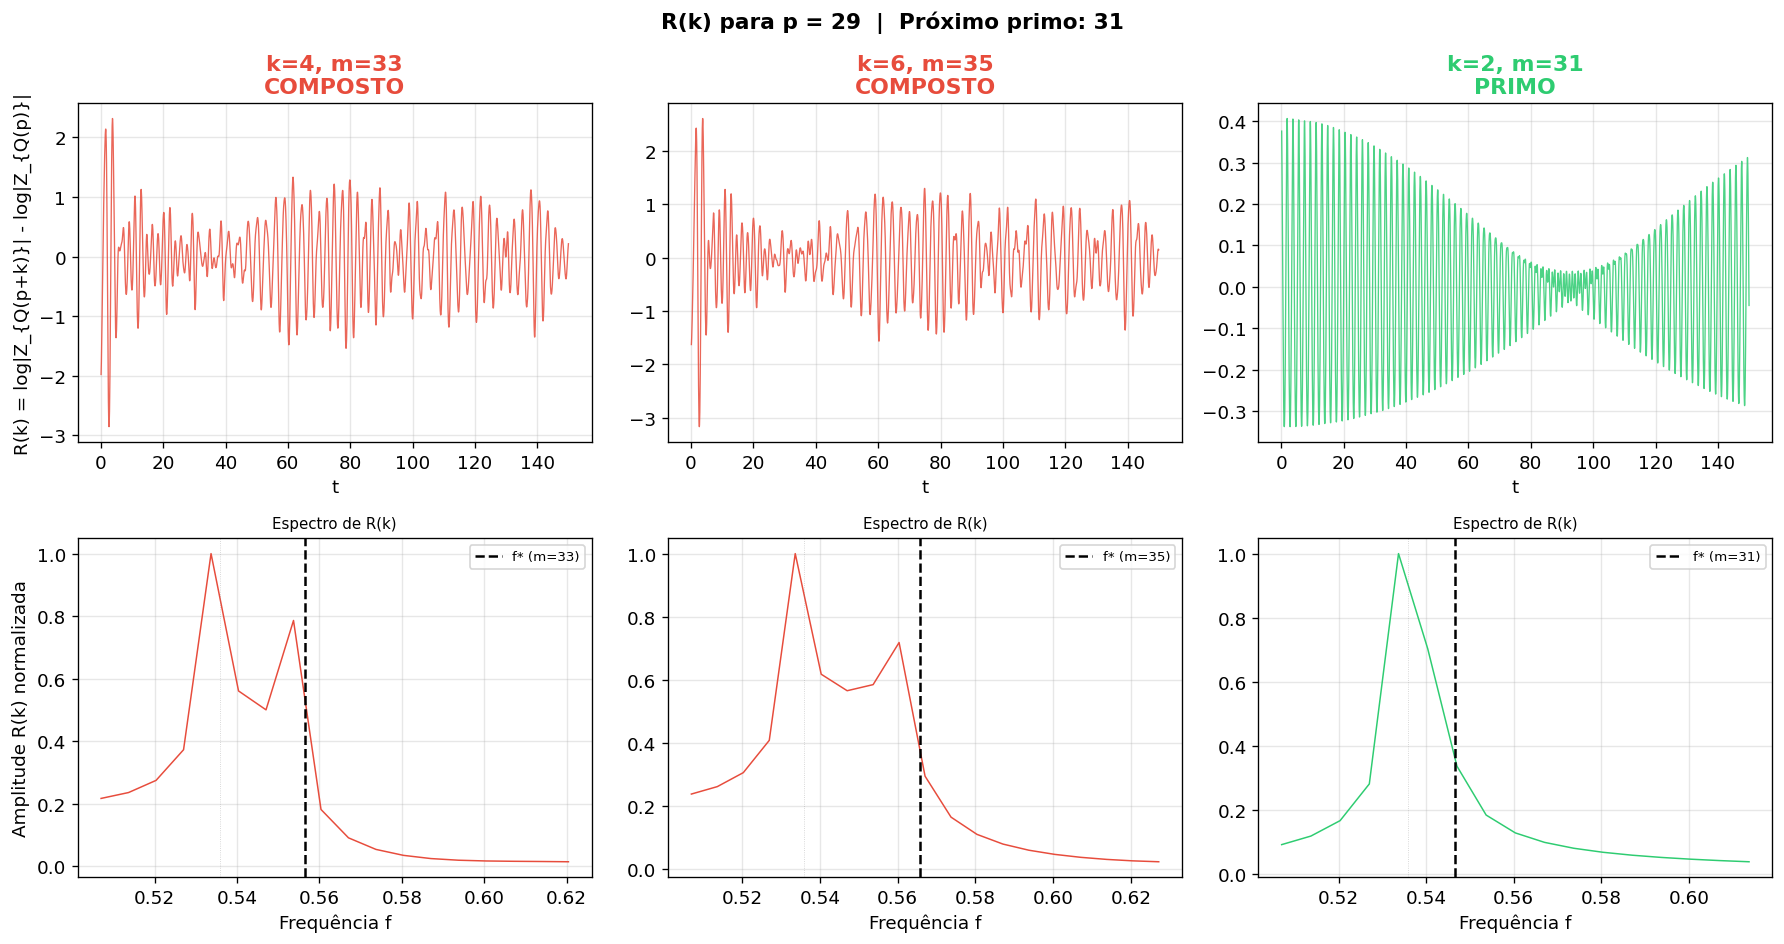

  Figura p=29 salva ✓


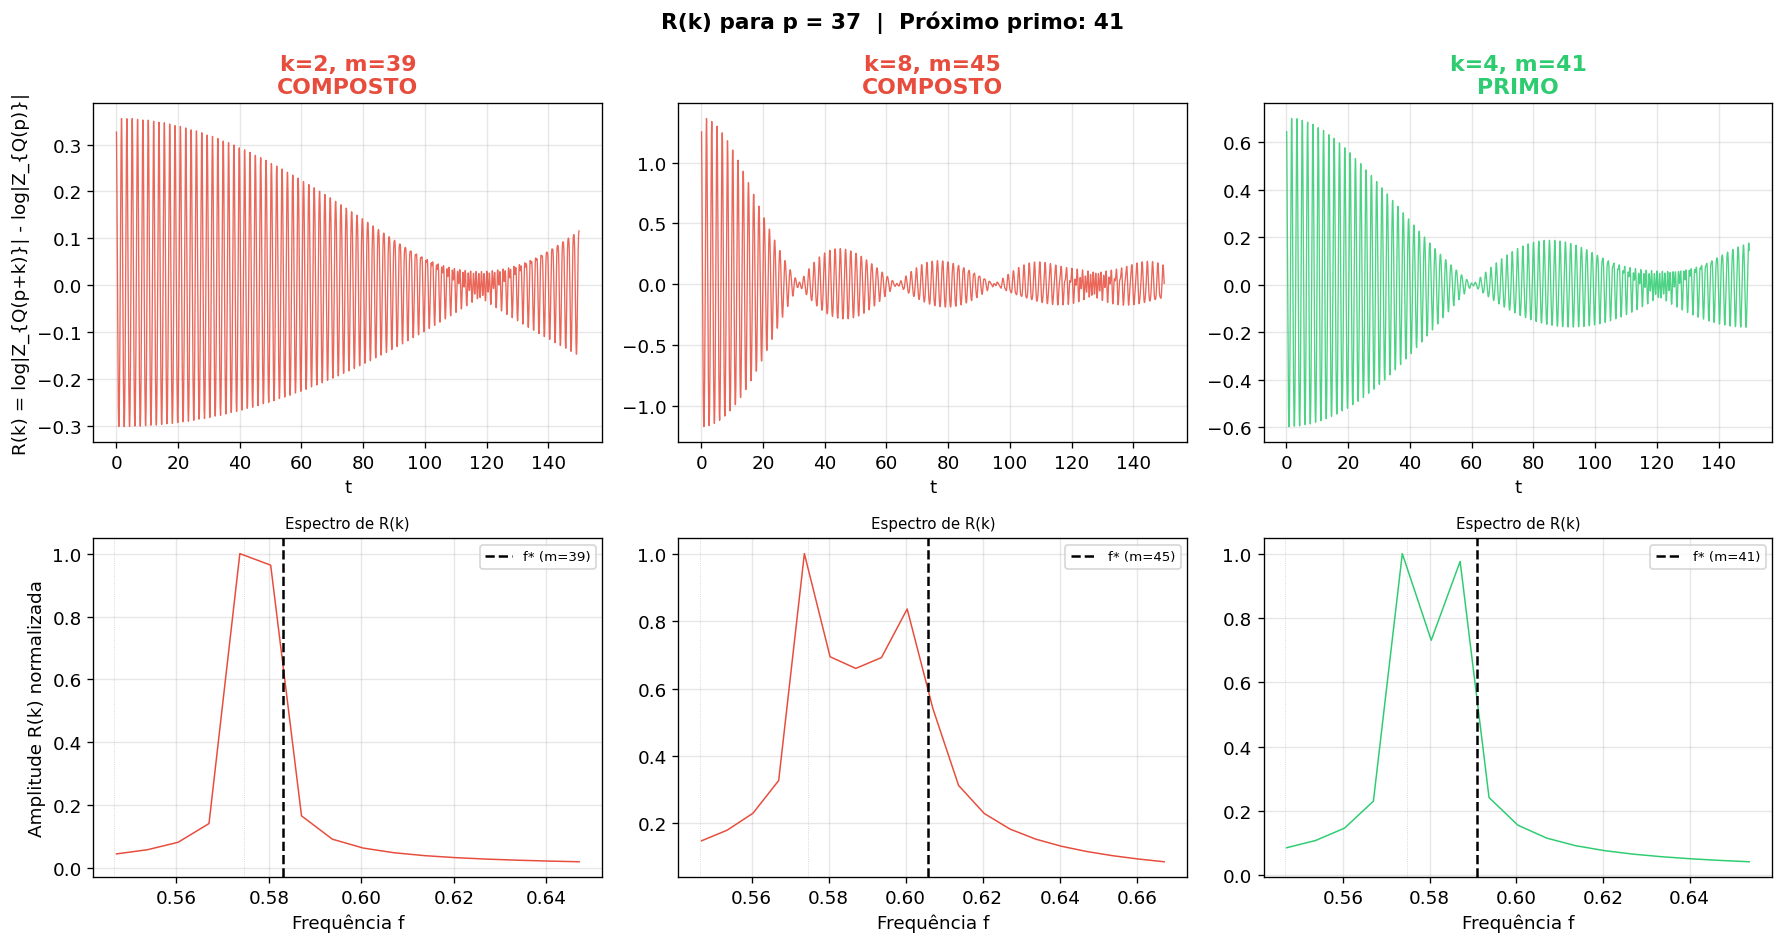

  Figura p=37 salva ✓


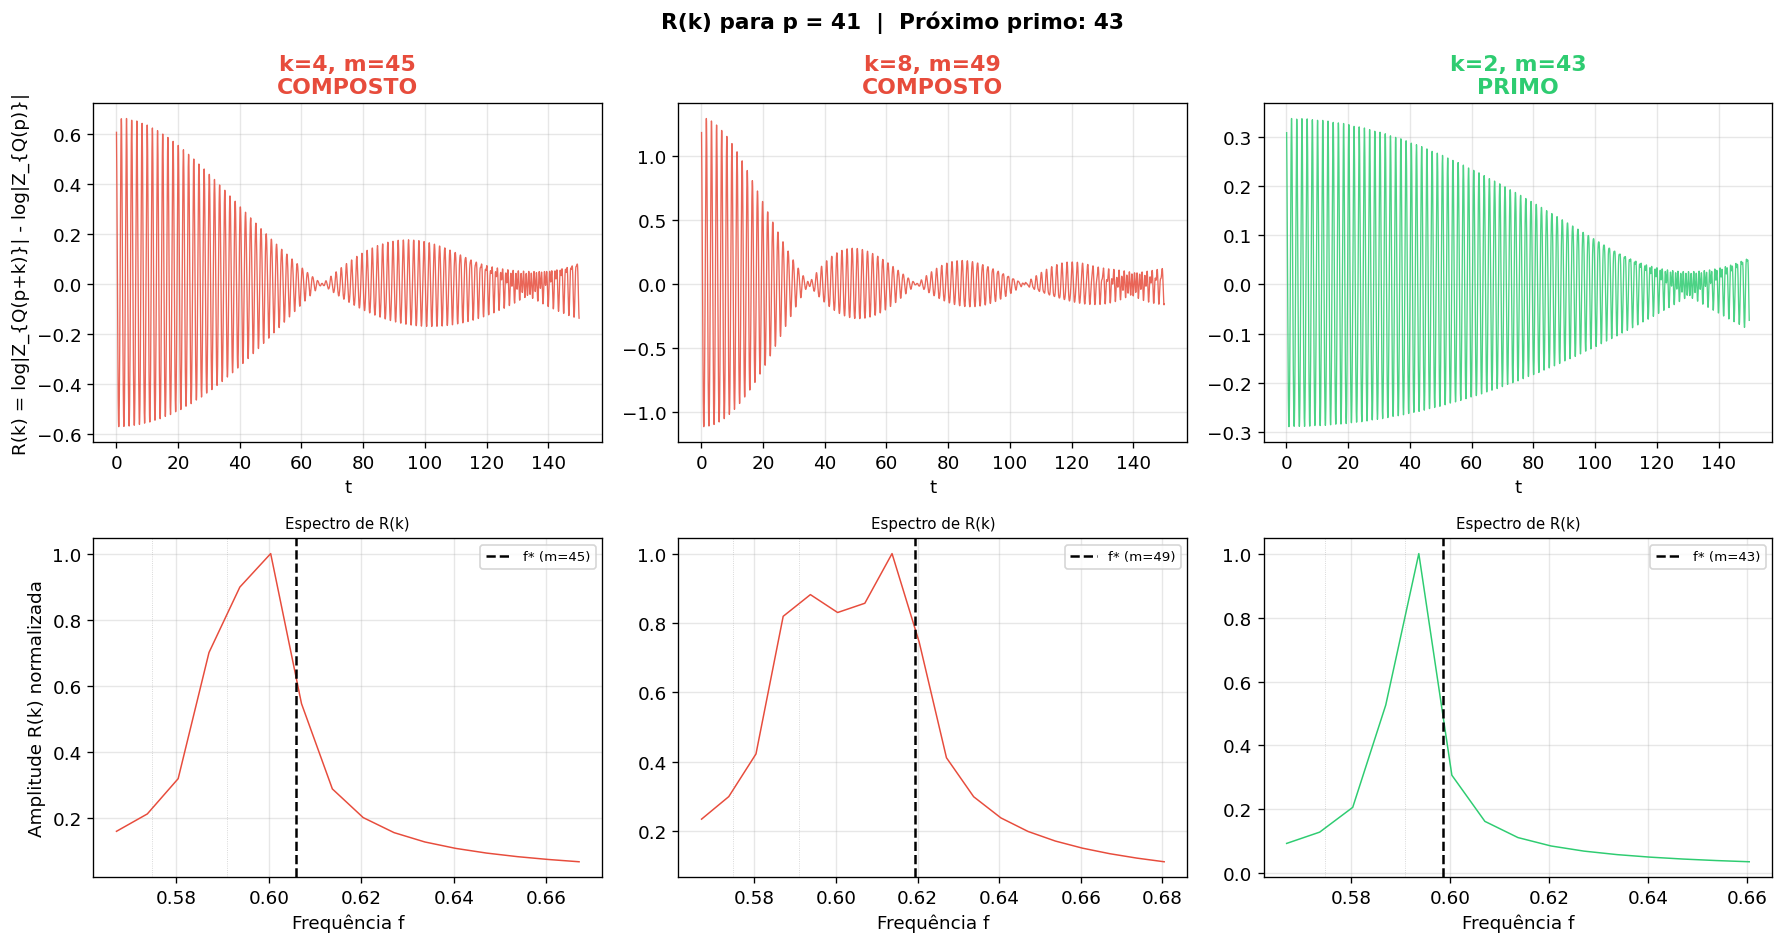

  Figura p=41 salva ✓


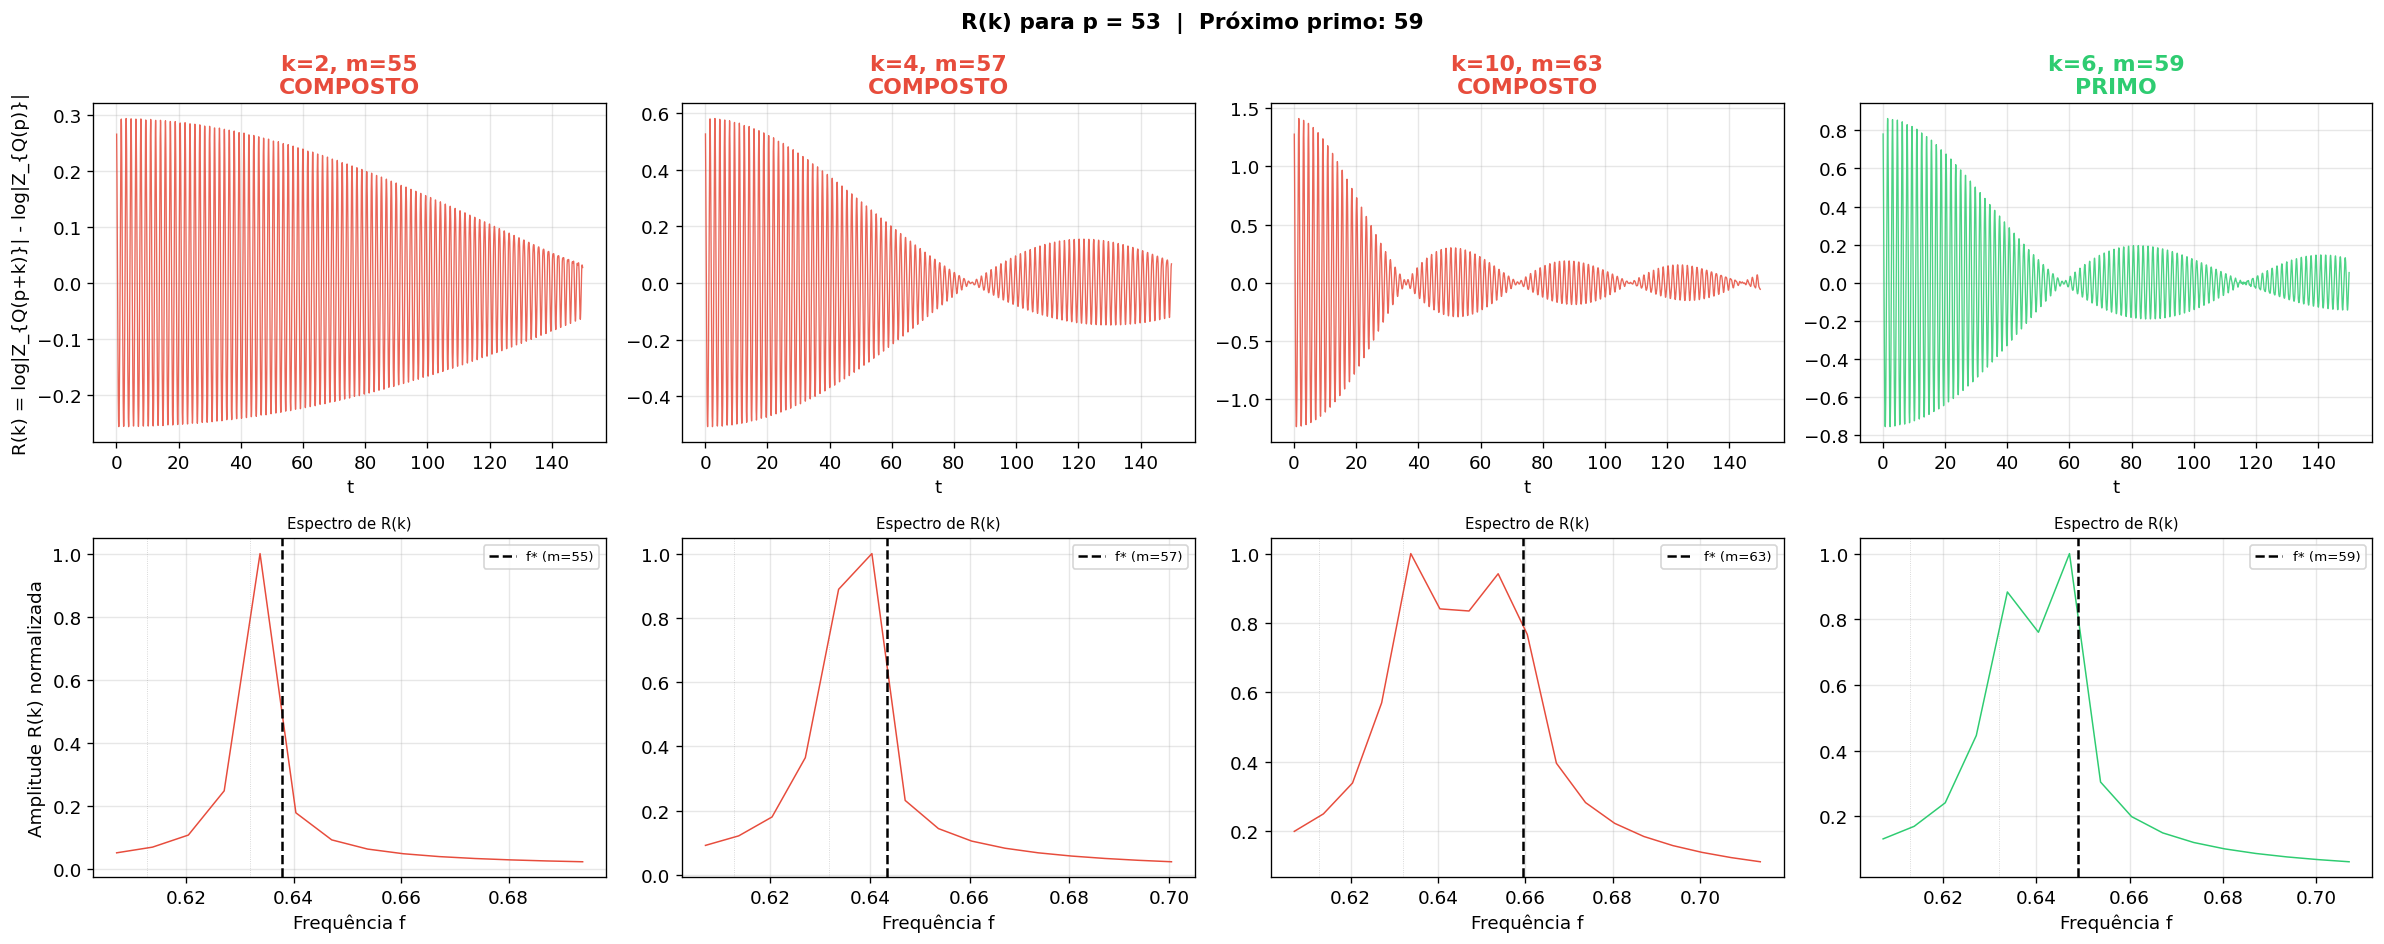

  Figura p=53 salva ✓


In [4]:
for p in PRIMOS_BASE:
    p_next = int(nextprime(p))
    sub    = [r for r in resultados if r['p'] == p]

    # Selecionar: próximo primo e até 3 compostos vizinhos
    primo_row    = [r for r in sub if r['primo']][0]
    compostos    = [r for r in sub if not r['primo']][:3]
    casos        = compostos + [primo_row]

    fig, axes = plt.subplots(2, len(casos), figsize=(5*len(casos), 8))
    fig.suptitle(f'R(k) para p = {p}  |  Próximo primo: {p_next}',
                 fontsize=13, fontweight='bold')

    for col, row in enumerate(casos):
        cor    = '#e74c3c' if not row['primo'] else '#2ecc71'
        titulo = f"k={row['k']}, m={row['m']}\n{'PRIMO' if row['primo'] else 'COMPOSTO'}"

        # Painel superior: R(k) no tempo
        ax = axes[0, col]
        ax.plot(t_vals, row['R'], color=cor, lw=0.8, alpha=0.85)
        ax.set_title(titulo, color=cor, fontweight='bold')
        ax.set_xlabel('t')
        if col == 0:
            ax.set_ylabel('R(k) = log|Z_{Q(p+k)}| - log|Z_{Q(p)}|')

        # Painel inferior: espectro de R(k)
        ax2 = axes[1, col]
        freq = row['freq']
        amp  = row['amp_R']
        f_min_plot = math.log(max(p-2, 3)) / (2*math.pi) - 0.02
        f_max_plot = math.log(row['m'] + 4) / (2*math.pi) + 0.05
        mask = (freq > f_min_plot) & (freq < f_max_plot)
        af, ff = amp[mask], freq[mask]
        if af.max() > 0:
            ax2.plot(ff, af / af.max(), color=cor, lw=0.9)

        # Linha vertical na frequência alvo f*
        ax2.axvline(row['f_alvo'], color='black', lw=1.5, ls='--', label=f'f* (m={row["m"]})')

        # Marcar primos conhecidos < p
        for q in primerange(2, p + 1):
            fq = math.log(q) / (2*math.pi)
            if f_min_plot <= fq <= f_max_plot:
                ax2.axvline(fq, color='gray', lw=0.5, alpha=0.4, ls=':')

        ax2.set_xlabel('Frequência f')
        if col == 0:
            ax2.set_ylabel('Amplitude R(k) normalizada')
        ax2.legend(fontsize=8)
        ax2.set_title('Espectro de R(k)', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'Rk_p{p}.png', bbox_inches='tight', dpi=130)
    plt.show()
    print(f'  Figura p={p} salva ✓')

## 4. Critério de detecção: irredutibilidade espectral

Para cada $R(k)$, verificamos se o pico máximo coincide com $f^*$ (frequência de $p+k$) ou com algum primo já conhecido.

**Critério proposto:**
- Se o pico máximo de $R(k)$ está em $f^* \pm \epsilon$ → candidato a primo
- Se o pico máximo está em alguma frequência de primo $q < p$ → composto (explicável)

In [5]:
TOLERANCIA = 0.008   # janela de frequência para considerar coincidência

primos_conhecidos_freqs = {q: math.log(q)/(2*math.pi) for q in primerange(2, 60)}

print(f'{"p":>4} | {"k":>4} | {"m":>5} | {"primo?":>7} | {"f*":>8} | {"f_max R":>8} | '
      f'{"Δf":>8} | {"redutível?":>12} | {"detecção":>10}')
print('-' * 85)

acertos = 0
total   = 0

for row in resultados:
    if row['amp_max'] == 0:
        continue

    f_alvo  = row['f_alvo']
    f_max_r = row['f_max']
    delta_f = abs(f_max_r - f_alvo)

    # Verificar se f_max coincide com primo conhecido
    redutivel = False
    primo_exp = None
    for q, fq in primos_conhecidos_freqs.items():
        if q >= row['m']:
            continue
        if abs(f_max_r - fq) < TOLERANCIA:
            redutivel = True
            primo_exp = q
            break

    # Critério: pico em f* e não redutível → prediz primo
    prediz_primo = (delta_f < TOLERANCIA) and (not redutivel)
    correto      = (prediz_primo == row['primo'])

    acertos += int(correto)
    total   += 1

    marcador = '✓' if correto else '✗'
    red_str  = f'sim({primo_exp})' if redutivel else 'não'
    det_str  = 'PRIMO' if prediz_primo else 'composto'

    print(f'{row["p"]:>4} | {row["k"]:>4} | {row["m"]:>5} | {str(row["primo"]):>7} | '
          f'{f_alvo:>8.5f} | {f_max_r:>8.5f} | {delta_f:>8.5f} | '
          f'{red_str:>12} | {det_str:>8} {marcador}')

print(f'\nTaxa de acertos do critério: {acertos}/{total} = {acertos/total:.1%}')

   p |    k |     m |  primo? |       f* |  f_max R |       Δf |   redutível? |   detecção
-------------------------------------------------------------------------------------
  29 |    2 |    31 |    True |  0.54654 |  0.53369 |  0.01285 |      sim(29) | composto ✗
  29 |    4 |    33 |   False |  0.55649 |  0.53369 |  0.02280 |      sim(29) | composto ✓
  29 |    6 |    35 |   False |  0.56585 |  0.53369 |  0.03216 |      sim(29) | composto ✓
  29 |    8 |    37 |    True |  0.57470 |  0.53369 |  0.04101 |      sim(29) | composto ✗
  37 |    2 |    39 |   False |  0.58307 |  0.57372 |  0.00936 |      sim(37) | composto ✓
  37 |    4 |    41 |    True |  0.59103 |  0.57372 |  0.01732 |      sim(37) | composto ✗
  37 |    6 |    43 |    True |  0.59861 |  0.57372 |  0.02490 |      sim(37) | composto ✗
  37 |    8 |    45 |   False |  0.60585 |  0.57372 |  0.03213 |      sim(37) | composto ✓
  37 |   10 |    47 |    True |  0.61277 |  0.57372 |  0.03905 |      sim(37) | composto ✗
  41

## 5. Análise do efeito de $t_{\max}$

Para um primo $p$ fixo e seu próximo primo $p' = p + k^*$, variamos $t_{\max}$ e medimos:
- Amplitude de $R(k^*)$ na frequência $f^*$ (sinal do primo)
- Amplitude de $R(k)$ em $f^*$ para o melhor composto vizinho (ruído)
- SNR = sinal / ruído

Isso responde empiricamente à Questão 1 da Nota 18: $t_{\max}$ precisa crescer com $p$?

In [6]:
T_MAX_VALS = [30, 50, 75, 100, 150, 200, 300]
P_TMAX     = [37, 53]   # primos para testar efeito de t_max

snr_data = {p: {'t_max': [], 'snr': [], 'amp_primo': [], 'amp_comp': []} for p in P_TMAX}

for p in P_TMAX:
    p_next = int(nextprime(p))
    k_star = p_next - p

    # Compostos vizinhos para medir ruído
    compostos_k = [k for k in range(2, k_star + 6, 2)
                   if k != k_star and not isprime(p + k)][:2]

    print(f'\np = {p}, próximo primo = {p_next}, k* = {k_star}')
    print(f'Compostos de referência: {[p+k for k in compostos_k]}')
    print(f'{"t_max":>8} | {"amp(primo)":>12} | {"amp(comp)":>12} | {"SNR":>8}')
    print('-' * 48)

    for t_max in T_MAX_VALS:
        tv     = np.arange(0.1, t_max, T_STEP)
        f_star = math.log(p_next) / (2*math.pi)
        f_min  = math.log(p) / (2*math.pi) - 0.01
        f_max  = f_star + 0.05

        # Sinal: amplitude de R(k*) em f*
        R_primo, _, _ = razao_R(p, k_star, tv)
        _, freq_p, amp_p = fft_picos(R_primo, T_STEP, f_min, f_max)
        a_primo = amplitude_em_f(f_star, freq_p, amp_p)

        # Ruído: amplitude média dos compostos em f*
        a_comps = []
        for kc in compostos_k:
            R_c, _, _ = razao_R(p, kc, tv)
            _, freq_c, amp_c = fft_picos(R_c, T_STEP, f_min, f_max)
            a_comps.append(amplitude_em_f(f_star, freq_c, amp_c))
        a_comp = np.mean(a_comps) if a_comps else 1

        snr = a_primo / a_comp if a_comp > 0 else float('inf')

        snr_data[p]['t_max'].append(t_max)
        snr_data[p]['amp_primo'].append(a_primo)
        snr_data[p]['amp_comp'].append(a_comp)
        snr_data[p]['snr'].append(snr)

        print(f'{t_max:>8} | {a_primo:>12.1f} | {a_comp:>12.1f} | {snr:>8.2f}')

print('\nAnálise t_max concluída ✓')


p = 37, próximo primo = 41, k* = 4
Compostos de referência: [39, 45]
   t_max |   amp(primo) |    amp(comp) |      SNR
------------------------------------------------
      30 |          0.0 |          0.0 |      inf
      50 |        225.9 |        177.4 |     1.27
      75 |        202.6 |        156.1 |     1.30
     100 |        192.7 |        157.4 |     1.22
     150 |        258.5 |        145.8 |     1.77
     200 |        229.6 |        152.5 |     1.51
     300 |        573.8 |        373.1 |     1.54

p = 53, próximo primo = 59, k* = 6
Compostos de referência: [55, 57]
   t_max |   amp(primo) |    amp(comp) |      SNR
------------------------------------------------
      30 |          0.0 |          0.0 |      inf
      50 |        267.7 |        152.9 |     1.75
      75 |        260.7 |        170.9 |     1.53
     100 |        229.9 |        163.5 |     1.41
     150 |        306.2 |        173.3 |     1.77
     200 |        303.1 |        170.2 |     1.78
     300 |  

## 6. Curva SNR vs. $t_{\max}$

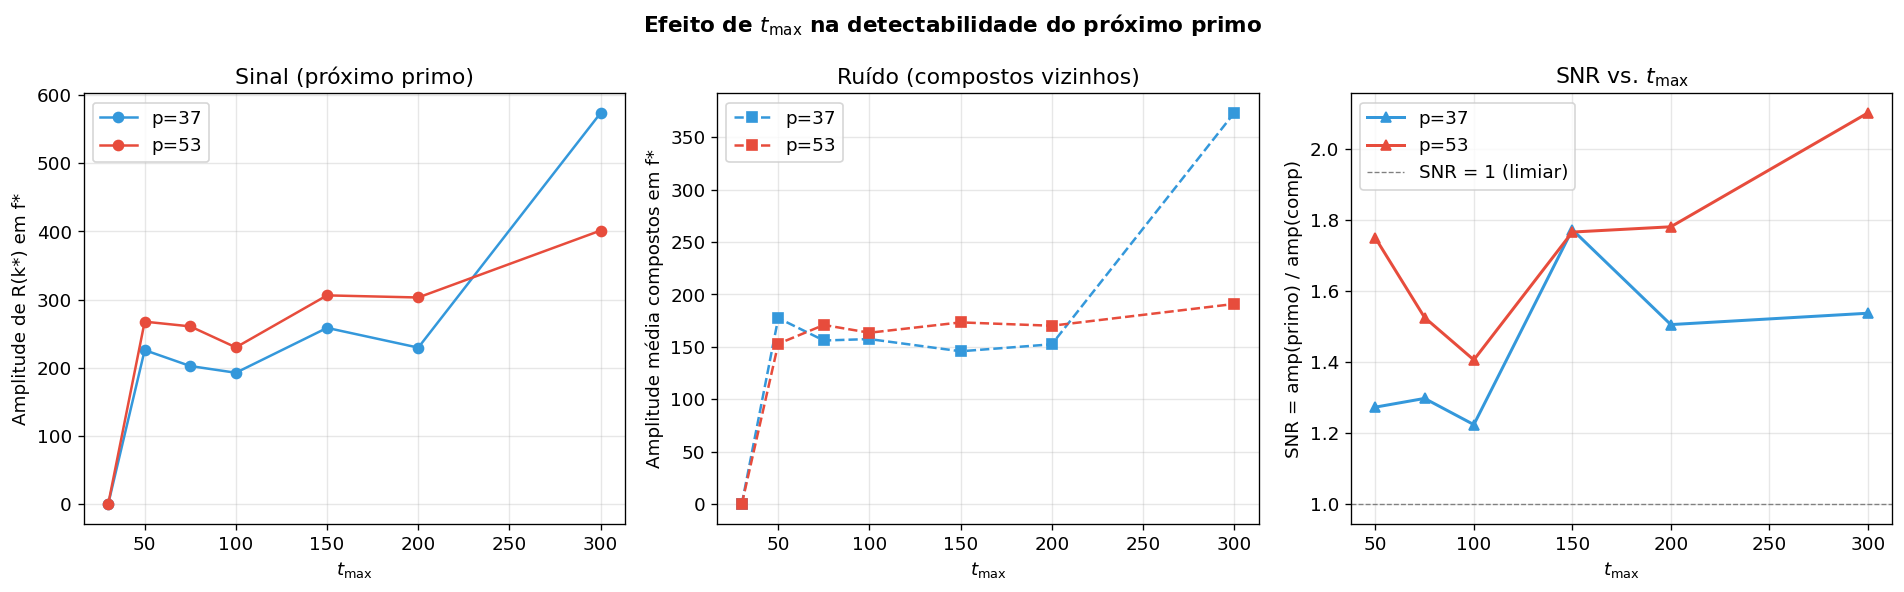

Figura SNR vs t_max salva ✓


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Efeito de $t_{\\max}$ na detectabilidade do próximo primo', fontsize=13, fontweight='bold')

cores_p = {37: '#3498db', 53: '#e74c3c'}

# Painel 1: amplitude do sinal (primo)
ax = axes[0]
for p in P_TMAX:
    d = snr_data[p]
    ax.plot(d['t_max'], d['amp_primo'], 'o-', color=cores_p[p], label=f'p={p}', lw=1.5)
ax.set_xlabel('$t_{\\max}$')
ax.set_ylabel('Amplitude de R(k*) em f*')
ax.set_title('Sinal (próximo primo)')
ax.legend()

# Painel 2: amplitude do ruído (compostos)
ax = axes[1]
for p in P_TMAX:
    d = snr_data[p]
    ax.plot(d['t_max'], d['amp_comp'], 's--', color=cores_p[p], label=f'p={p}', lw=1.5)
ax.set_xlabel('$t_{\\max}$')
ax.set_ylabel('Amplitude média compostos em f*')
ax.set_title('Ruído (compostos vizinhos)')
ax.legend()

# Painel 3: SNR
ax = axes[2]
for p in P_TMAX:
    d = snr_data[p]
    ax.plot(d['t_max'], d['snr'], '^-', color=cores_p[p], label=f'p={p}', lw=1.8)
ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='SNR = 1 (limiar)')
ax.set_xlabel('$t_{\\max}$')
ax.set_ylabel('SNR = amp(primo) / amp(comp)')
ax.set_title('SNR vs. $t_{\\max}$')
ax.legend()

plt.tight_layout()
plt.savefig('snr_tmax.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura SNR vs t_max salva ✓')

## 7. Comportamento de R(k) para gap grande vs. gap pequeno

Primos gêmeos ($gap = 2$) são o caso mais difícil — dois primos consecutivos com frequências muito próximas. Testamos se $R(k)$ ainda discrimina corretamente.

In [8]:
# Pares com gap pequeno (2 ou 4) e grande (>= 6)
pares_gap = []
p = 5
while p < 100:
    p2 = int(nextprime(p))
    pares_gap.append((p, p2, p2 - p))
    p = p2

print('Pares (p, p_next, gap):')
for trio in pares_gap:
    print(f'  {trio}')

# Para cada par, medir amplitude de R(k*) em f* com t_max padrão
print(f'\n{"p":>5} | {"p_next":>7} | {"gap":>5} | {"amp R@f*":>10} | {"t_min_teoria":>14}')
print('-' * 55)

gap_data = []
for p, p_next, gap in pares_gap:
    k_star   = gap
    f_star   = math.log(p_next) / (2*math.pi)
    f_min    = math.log(p) / (2*math.pi) - 0.01
    f_max    = f_star + 0.05

    # t_min teórico para separar p e p_next
    delta_f  = math.log(p_next/p) / (2*math.pi)
    t_min_th = 1.0 / delta_f if delta_f > 0 else float('inf')

    R, _, _  = razao_R(p, k_star, t_vals)
    _, freq, amp = fft_picos(R, T_STEP, f_min, f_max)
    a = amplitude_em_f(f_star, freq, amp)

    gap_data.append({'p': p, 'p_next': p_next, 'gap': gap,
                     'amp': a, 't_min_th': t_min_th})
    print(f'{p:>5} | {p_next:>7} | {gap:>5} | {a:>10.1f} | {t_min_th:>14.1f}')

Pares (p, p_next, gap):
  (5, 7, 2)
  (7, 11, 4)
  (11, 13, 2)
  (13, 17, 4)
  (17, 19, 2)
  (19, 23, 4)
  (23, 29, 6)
  (29, 31, 2)
  (31, 37, 6)
  (37, 41, 4)
  (41, 43, 2)
  (43, 47, 4)
  (47, 53, 6)
  (53, 59, 6)
  (59, 61, 2)
  (61, 67, 6)
  (67, 71, 4)
  (71, 73, 2)
  (73, 79, 6)
  (79, 83, 4)
  (83, 89, 6)
  (89, 97, 8)
  (97, 101, 4)

    p |  p_next |   gap |   amp R@f* |   t_min_teoria
-------------------------------------------------------
    5 |       7 |     2 |       81.1 |           18.7
    7 |      11 |     4 |       54.6 |           13.9
   11 |      13 |     2 |      180.2 |           37.6
   13 |      17 |     4 |       50.6 |           23.4
   17 |      19 |     2 |      390.8 |           56.5
   19 |      23 |     4 |      386.9 |           32.9
   23 |      29 |     6 |      293.8 |           27.1
   29 |      31 |     2 |      181.1 |           94.2
   31 |      37 |     6 |      213.5 |           35.5
   37 |      41 |     4 |      258.5 |           61.2
   41

## 8. Amplitude vs. gap: visualização

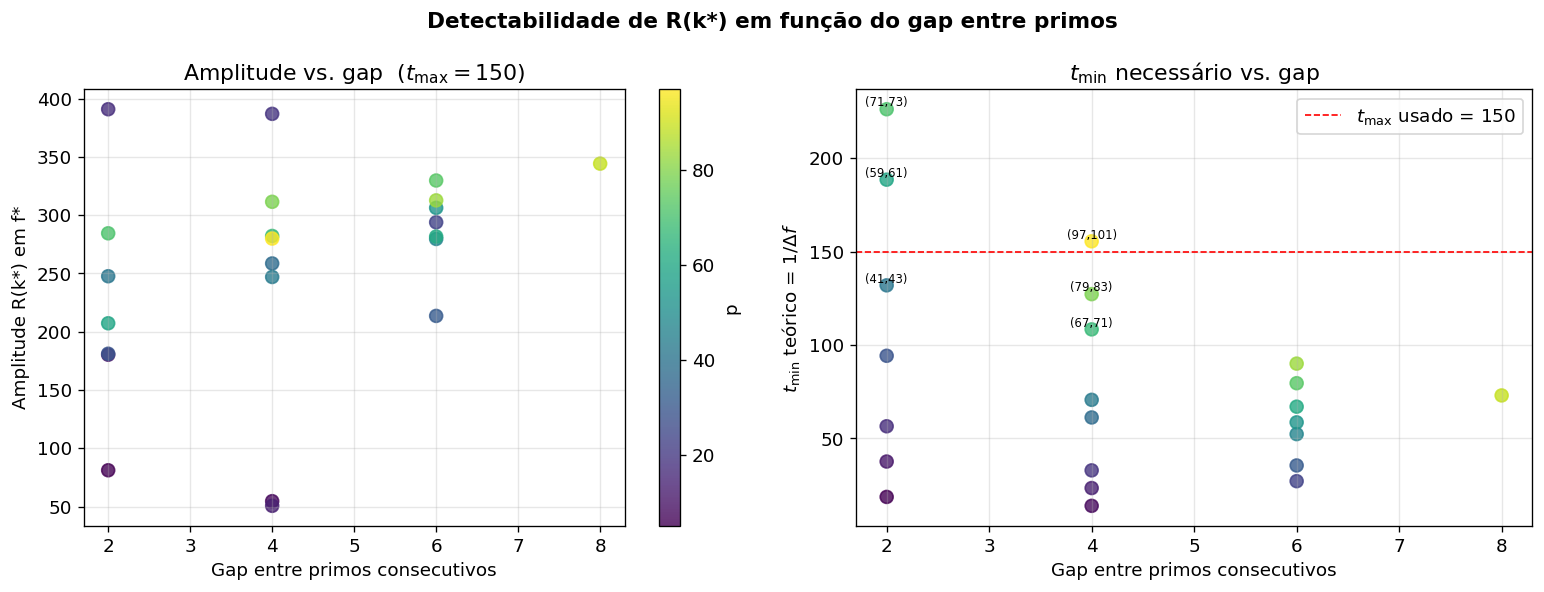

Figura amplitude vs gap salva ✓


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Detectabilidade de R(k*) em função do gap entre primos', fontsize=13, fontweight='bold')

gaps  = [d['gap']      for d in gap_data]
amps  = [d['amp']      for d in gap_data]
tmins = [d['t_min_th'] for d in gap_data]
ps    = [d['p']        for d in gap_data]

# Amplitude vs gap
ax = axes[0]
sc = ax.scatter(gaps, amps, c=ps, cmap='viridis', s=60, alpha=0.8)
plt.colorbar(sc, ax=ax, label='p')
ax.set_xlabel('Gap entre primos consecutivos')
ax.set_ylabel('Amplitude R(k*) em f*')
ax.set_title(f'Amplitude vs. gap  ($t_{{\\max}}={T_MAX}$)')

# t_min teórico vs gap
ax2 = axes[1]
ax2.scatter(gaps, tmins, c=ps, cmap='viridis', s=60, alpha=0.8)
ax2.axhline(T_MAX, color='red', ls='--', lw=1, label=f'$t_{{\\max}}$ usado = {T_MAX}')
ax2.set_xlabel('Gap entre primos consecutivos')
ax2.set_ylabel('$t_{\\min}$ teórico = $1/\\Delta f$')
ax2.set_title('$t_{\\min}$ necessário vs. gap')
ax2.legend()
# Anotar pares com t_min > t_max
for d in gap_data:
    if d['t_min_th'] > T_MAX * 0.7:
        ax2.annotate(f"({d['p']},{d['p_next']})",
                     (d['gap'], d['t_min_th']),
                     fontsize=7, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('amp_vs_gap.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura amplitude vs gap salva ✓')

## 9. Resumo do critério e implicações para t_max

In [10]:
import pandas as pd

print('=== RESUMO DO CRITÉRIO DE IRREDUTIBILIDADE ESPECTRAL ===')
print()

# Taxa de acerto geral
n_total   = sum(1 for r in resultados if r['amp_max'] > 0)
n_primos  = sum(1 for r in resultados if r['primo'])
n_comp    = sum(1 for r in resultados if not r['primo'])
print(f'  Casos testados: {n_total}  ({n_primos} primos, {n_comp} compostos)')
print()

# Distribuição de amplitude para primos vs compostos
amps_primos = [r['amp_alvo'] for r in resultados if r['primo'] and r['amp_max'] > 0]
amps_comps  = [r['amp_alvo'] for r in resultados if not r['primo'] and r['amp_max'] > 0]

if amps_primos:
    print(f'  Amplitude R@f* para PRIMOS  : média={np.mean(amps_primos):.1f}, '
          f'min={np.min(amps_primos):.1f}, max={np.max(amps_primos):.1f}')
if amps_comps:
    print(f'  Amplitude R@f* para COMPOSTOS: média={np.mean(amps_comps):.1f}, '
          f'min={np.min(amps_comps):.1f}, max={np.max(amps_comps):.1f}')

print()
print('=== IMPLICAÇÕES PARA t_max (Questão 1 da Nota 18) ===')
print()
for d in gap_data:
    status = 'OK' if d['t_min_th'] <= T_MAX else 'INSUFICIENTE'
    print(f'  p={d["p"]:>3}, p_next={d["p_next"]:>3}, gap={d["gap"]:>2}: '
          f't_min_teoria={d["t_min_th"]:>7.1f}  [{status}]')

print()
gaps_problema = [d for d in gap_data if d['t_min_th'] > T_MAX]
if gaps_problema:
    print(f'  Pares que exigem t_max > {T_MAX}:')
    for d in gaps_problema:
        print(f'    ({d["p"]}, {d["p_next"]}): gap={d["gap"]}, t_min={d["t_min_th"]:.1f}')
else:
    print(f'  Todos os pares testados têm t_min_teoria <= {T_MAX}.')

print()
# Crescimento de t_min com p
print('  Tendência de t_min com p:')
print(f'  {"p":>5} | {"gap":>5} | {"t_min":>10}')
for d in gap_data[::3]:
    print(f'  {d["p"]:>5} | {d["gap"]:>5} | {d["t_min_th"]:>10.1f}')

=== RESUMO DO CRITÉRIO DE IRREDUTIBILIDADE ESPECTRAL ===

  Casos testados: 19  (9 primos, 10 compostos)

  Amplitude R@f* para PRIMOS  : média=252.6, min=181.1, max=306.2
  Amplitude R@f* para COMPOSTOS: média=263.1, min=219.0, max=322.7

=== IMPLICAÇÕES PARA t_max (Questão 1 da Nota 18) ===

  p=  5, p_next=  7, gap= 2: t_min_teoria=   18.7  [OK]
  p=  7, p_next= 11, gap= 4: t_min_teoria=   13.9  [OK]
  p= 11, p_next= 13, gap= 2: t_min_teoria=   37.6  [OK]
  p= 13, p_next= 17, gap= 4: t_min_teoria=   23.4  [OK]
  p= 17, p_next= 19, gap= 2: t_min_teoria=   56.5  [OK]
  p= 19, p_next= 23, gap= 4: t_min_teoria=   32.9  [OK]
  p= 23, p_next= 29, gap= 6: t_min_teoria=   27.1  [OK]
  p= 29, p_next= 31, gap= 2: t_min_teoria=   94.2  [OK]
  p= 31, p_next= 37, gap= 6: t_min_teoria=   35.5  [OK]
  p= 37, p_next= 41, gap= 4: t_min_teoria=   61.2  [OK]
  p= 41, p_next= 43, gap= 2: t_min_teoria=  131.9  [OK]
  p= 43, p_next= 47, gap= 4: t_min_teoria=   70.6  [OK]
  p= 47, p_next= 53, gap= 6: t_mi